In [1]:
print("ahmed")

ahmed


In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

/home/ahmed/miniconda3/envs/ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
docs = (
    PyPDFLoader("documents/data/AI_Engineer-page1.pdf").load()
    + PyPDFLoader("documents/data/Tanvir_Ahmed_Enterprise_Demo_RAG_Knowledge_Base.pdf").load()
    + PyPDFLoader("documents/data/Tanvir_Ahmed_RAG_Knowledge_Base.pdf").load()
)


In [4]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=100, chunk_overlap=20
).split_documents(docs)

In [5]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [6]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [7]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]

    answer: str

In [8]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [9]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [28]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

def generate(state: State):

    context = "\n\n".join(
        doc.page_content
        for doc in state["docs"]
    )

    response = llm.invoke(
        f"""
        Answer the question using ONLY the context.

        Context:
        {context}

        Question:
        {state["question"]}
        """
    )

    return {
        "answer": response.content
    }

In [11]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [29]:
g = StateGraph(State)

# Nodes
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)

# START
g.add_edge(START, "decide_retrieval")

# Routing
g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

# Direct path
g.add_edge("generate_direct", END)

# RAG path
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)

app = g.compile()

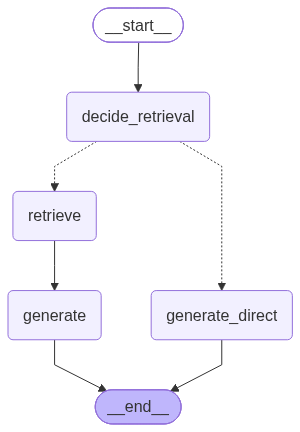

In [26]:
app

In [30]:
result = app.invoke(
    {
        "question": "who is tanvir ahmed",
        "need_retrieval":"",
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])
print(result['need_retrieval'])
print(result['docs'])

Tanvir Ahmed is a professional whose contact information includes the email tanvirahmed754575@gmail.com.
True
[Document(id='e4ec33ca-94ba-46fc-8546-3091845a8cbb', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-29T09:05:07+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-29T09:05:07+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'documents/data/Tanvir_Ahmed_RAG_Knowledge_Base.pdf', 'total_pages': 6, 'page': 5, 'page_label': '6'}, page_content='Professional Contact Information\nName: Tanvir Ahmed\nEmail: tanvirahmed754575@gmail.com'), Document(id='bdff58f0-0951-4987-878c-51d96cb1f778', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-29T09:05:07+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-29T09:05:07+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped'

In [31]:
result = app.invoke(
    {
        "question": "who is Bappy Ahmed",
        "need_retrieval":"",
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])
print(result['need_retrieval'])
print(result['docs'])

The context does not provide any information about Bappy Ahmed.
True
[Document(id='9242d400-c898-4da4-917e-86eb7d6b3bf2', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-29T09:12:14+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-29T09:12:14+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'documents/data/Tanvir_Ahmed_Enterprise_Demo_RAG_Knowledge_Base.pdf', 'total_pages': 15, 'page': 5, 'page_label': '6'}, page_content='Employee ID: EMP-005\nName: Ahmed Rahman\nJob Title: MLOps Engineer'), Document(id='e4ec33ca-94ba-46fc-8546-3091845a8cbb', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-29T09:05:07+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-29T09:05:07+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'documents/data/Tanvir_

In [32]:

print(result["answer"])

The context does not provide any information about Bappy Ahmed.


In [18]:
result = app.invoke(
    {
        "question": "What is llm",
        "need_retrieval":"",
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])
print(result['need_retrieval'])
print(result['docs'])

LLM can refer to a few different things depending on the context:

1. **Master of Laws (LL.M.)**: This is a postgraduate academic degree in law. It is typically pursued by individuals who already hold a law degree and wish to specialize in a particular area of law or enhance their legal knowledge.

2. **Large Language Model (LLM)**: In the context of artificial intelligence and natural language processing, an LLM refers to a type of AI model that is trained on vast amounts of text data to understand and generate human-like language. Examples include models like GPT-3 and BERT.

If you have a specific context in mind, please clarify!
False
[]


In [19]:
result['answer']

'LLM can refer to a few different things depending on the context:\n\n1. **Master of Laws (LL.M.)**: This is a postgraduate academic degree in law. It is typically pursued by individuals who already hold a law degree and wish to specialize in a particular area of law or enhance their legal knowledge.\n\n2. **Large Language Model (LLM)**: In the context of artificial intelligence and natural language processing, an LLM refers to a type of AI model that is trained on vast amounts of text data to understand and generate human-like language. Examples include models like GPT-3 and BERT.\n\nIf you have a specific context in mind, please clarify!'